# **Perbandingan Algoritma Machine Learning dalam Memprediksi Traffic Volume pada Jalan Tol Interstate I-94 Menggunakan Data Cuaca dan Waktu**

# Sumber Dataset
Dataset yang digunakan berasal dari Kaggle, yaitu platform yang menyediakan berbagai dataset untuk pembelajaran dan penelitian di bidang data science dan machine learning.

Dataset ini berisi data volume lalu lintas pada jalan tol Metro Interstate dengan target traffic_volume, yang digunakan untuk menganalisis dan memprediksi jumlah kendaraan berdasarkan waktu, kondisi cuaca, dan hari libur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [4]:
df = pd.read_excel('Metro_Interstate_Traffic_Volume.csv.xlsx')

print(df.columns)
df.head()

Index(['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
       'weather_main', 'weather_description', 'date_time'],
      dtype='object')


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


# DATA UNDERSTANDING

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              61 non-null     object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


,0
traffic_volume,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0


# PREPROCESSING

In [6]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date_time'])

In [7]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek

In [8]:
df = df.drop(['date_time'], axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['holiday'] = le.fit_transform(df['holiday'])
df['weather_main'] = le.fit_transform(df['weather_main'])
df['weather_description'] = le.fit_transform(df['weather_description'])

In [21]:
df.isnull().sum()

,0
traffic_volume,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
hour,0
day,0


In [22]:
print(X.columns)

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'hour', 'day', 'month', 'day_of_week'],
      dtype='object')


# EDA

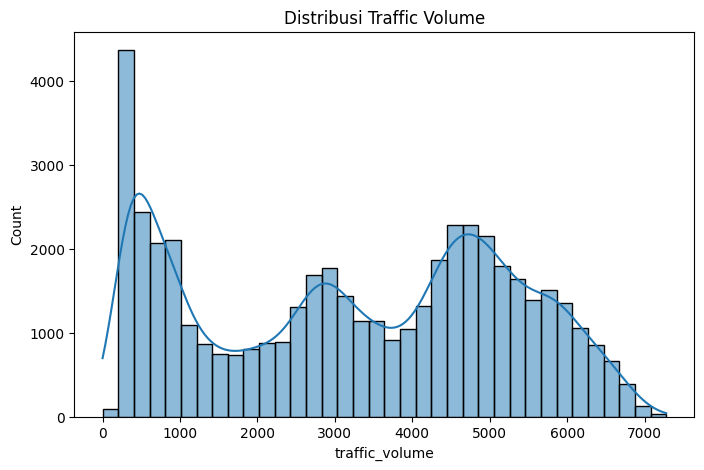

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], kde=True)
plt.title("Distribusi Traffic Volume")
plt.show()

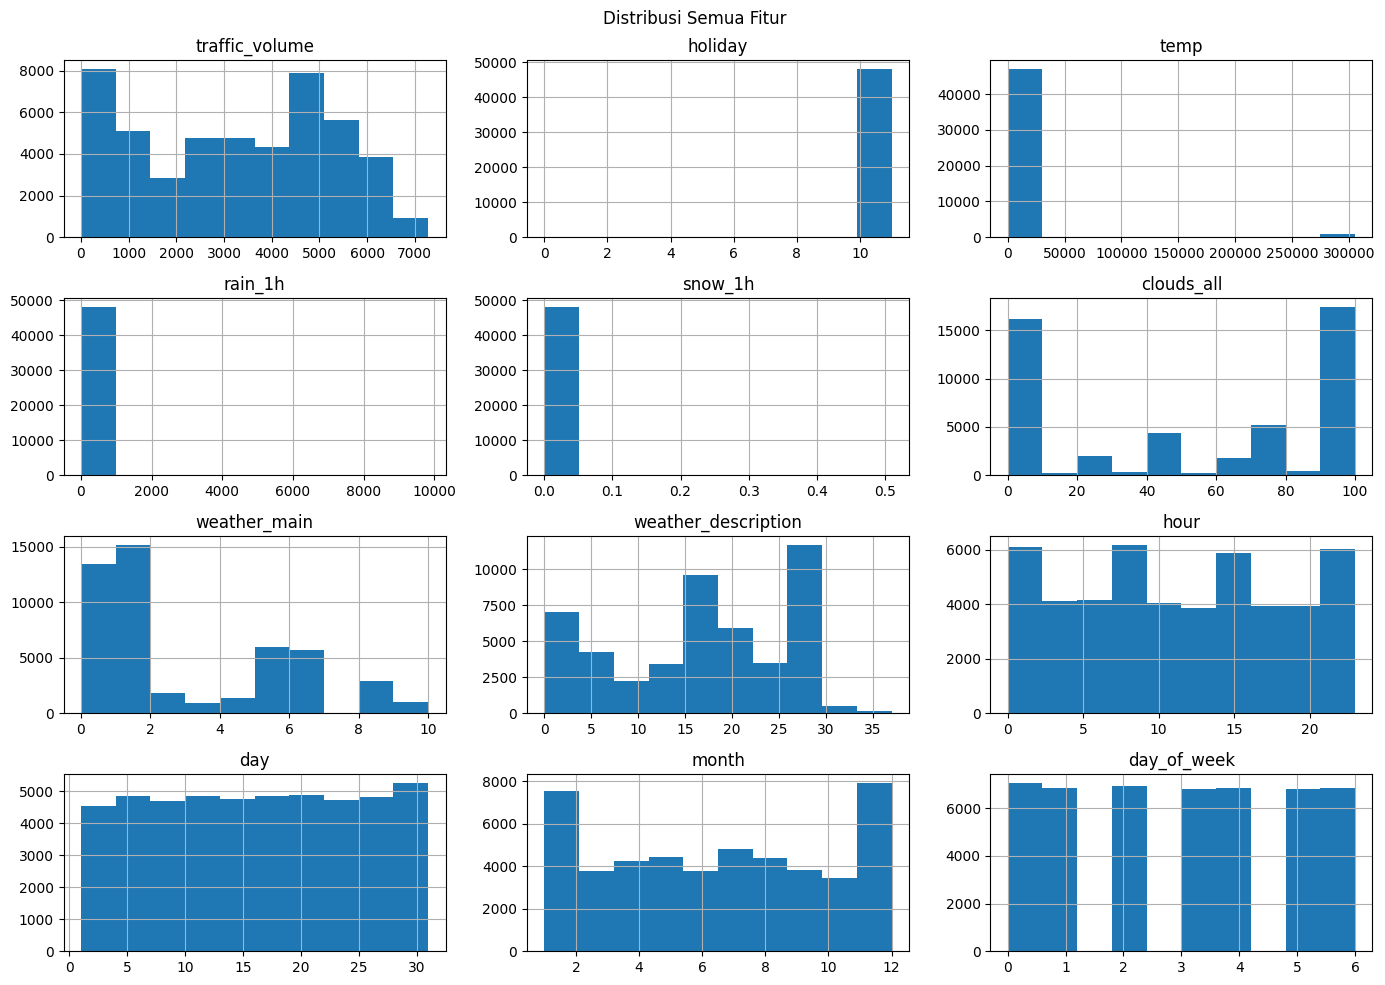

In [11]:
df.hist(figsize=(14,10))
plt.suptitle("Distribusi Semua Fitur")
plt.tight_layout()
plt.show()

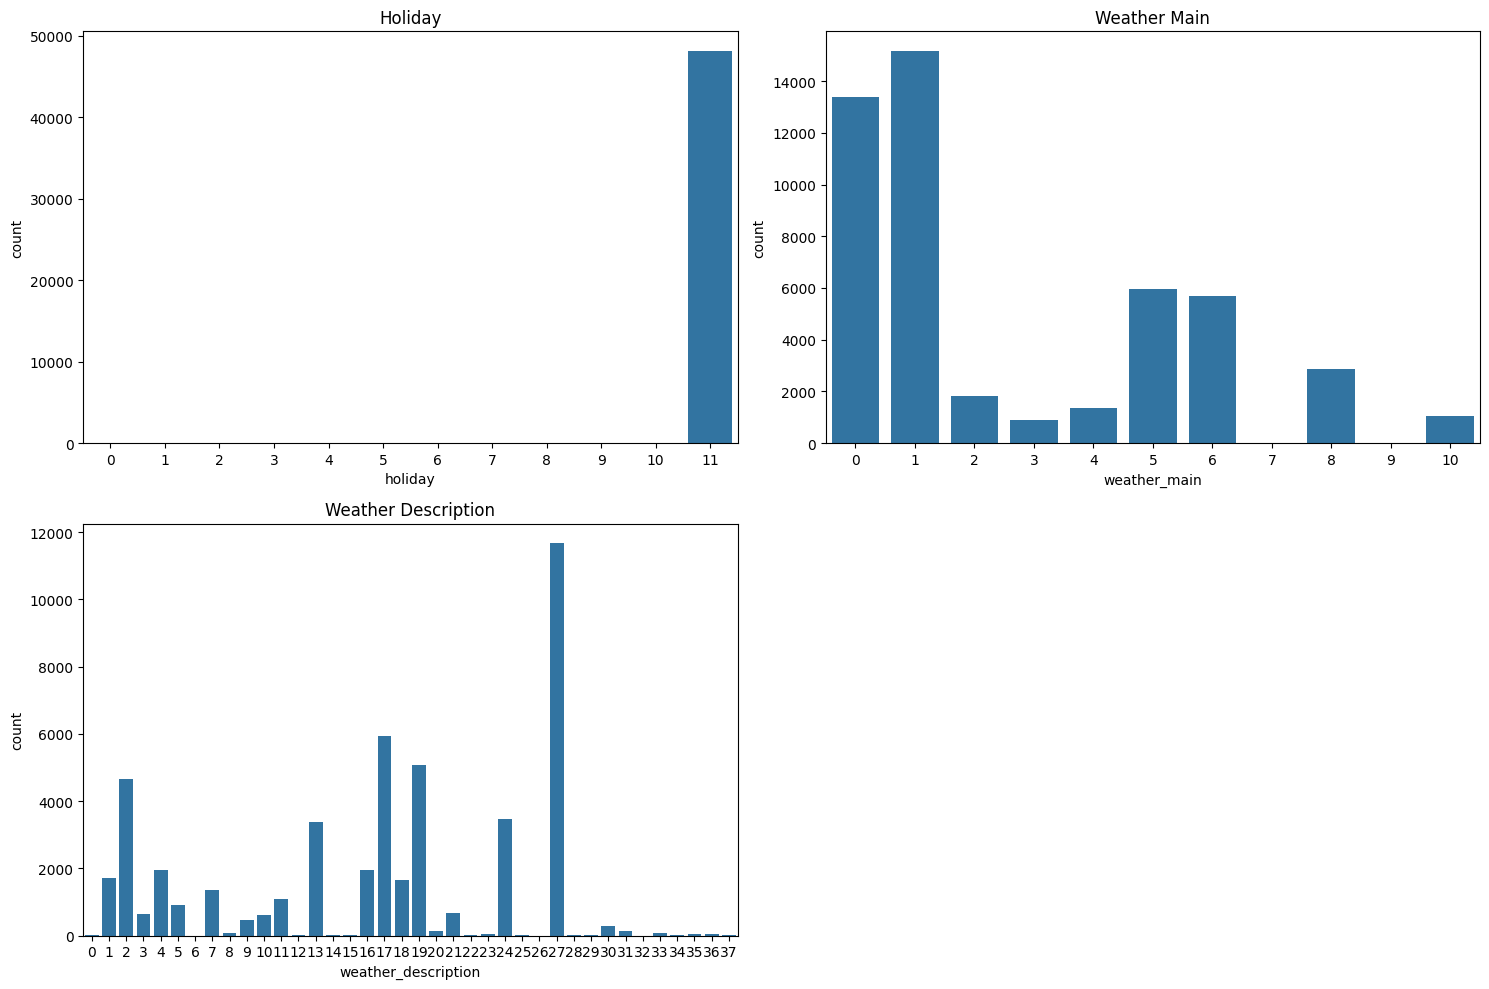

In [12]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(x=df['holiday'])
plt.title("Holiday")

plt.subplot(2,2,2)
sns.countplot(x=df['weather_main'])
plt.title("Weather Main")

plt.subplot(2,2,3)
sns.countplot(x=df['weather_description'])
plt.title("Weather Description")

plt.tight_layout()
plt.show()

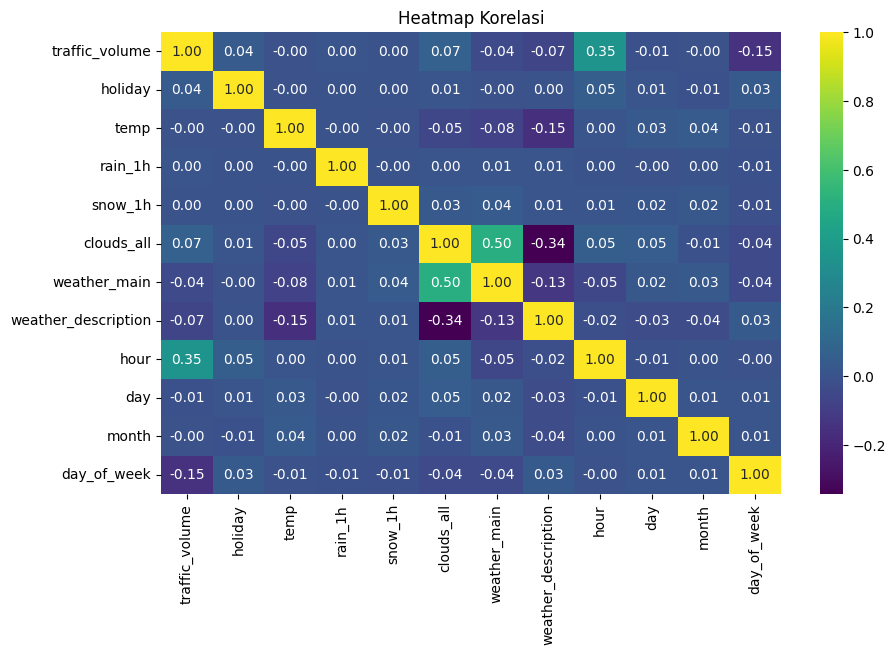

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='viridis')
plt.title("Heatmap Korelasi")
plt.show()

# FITUR DAN TARGET

In [14]:
X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

# DATA SPLITTING

In [15]:
from sklearn.model_selection import train_test_split

splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

# MODEL DAN TUNING

In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42
    )
}

# EVALUASI & MODEL

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = []

for split_name, test_size in splits.items():
    print(f"\n=== SPLIT {split_name} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"{model_name} | R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

        results.append({
            "Splitting": split_name,
            "Algorithm": model_name,
            "R2_Score": r2,
            "MAE": mae,
            "RMSE": rmse
        })


=== SPLIT 70:30 ===
XGBoost | R2: 0.9728 | MAE: 208.80 | RMSE: 328.74
Gradient Boosting | R2: 0.9587 | MAE: 249.73 | RMSE: 405.16
Random Forest | R2: 0.9617 | MAE: 229.87 | RMSE: 390.03

=== SPLIT 80:20 ===
XGBoost | R2: 0.9720 | MAE: 207.77 | RMSE: 332.69
Gradient Boosting | R2: 0.9576 | MAE: 248.45 | RMSE: 409.47
Random Forest | R2: 0.9608 | MAE: 226.95 | RMSE: 393.77

=== SPLIT 90:10 ===
XGBoost | R2: 0.9720 | MAE: 206.81 | RMSE: 333.09
Gradient Boosting | R2: 0.9569 | MAE: 249.65 | RMSE: 413.46
Random Forest | R2: 0.9605 | MAE: 225.99 | RMSE: 395.45


In [18]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Splitting", "R2_Score"],
    ascending=[True, False]
)

print("\n--- Tabel Perbandingan Akhir ---")
results_df


--- Tabel Perbandingan Akhir ---


,Splitting,Algorithm,R2_Score,MAE,RMSE
0,70:30,XGBoost,0.972823,208.801483,328.738153
2,70:30,Random Forest,0.961744,229.871500,390.030902
1,70:30,Gradient Boosting,0.958718,249.734503,405.159987
3,80:20,XGBoost,0.972004,207.766464,332.689267
5,80:20,Random Forest,0.960781,226.952346,393.768814
4,80:20,Gradient Boosting,0.957591,248.452824,409.467107
6,90:10,XGBoost,0.972011,206.806854,333.086595
8,90:10,Random Forest,0.960549,225.988717,395.454220
7,90:10,Gradient Boosting,0.956875,249.646268,413.456893


# GRAFIK

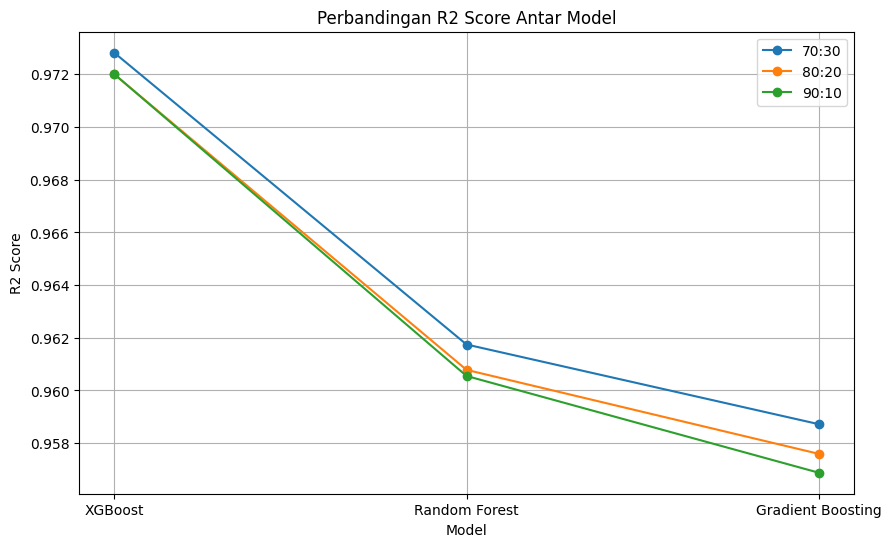

In [19]:
plt.figure(figsize=(10,6))

for split in splits.keys():
    subset = results_df[results_df['Splitting'] == split]
    plt.plot(subset['Algorithm'], subset['R2_Score'], marker='o', label=split)

plt.title("Perbandingan R2 Score Antar Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

holiday = widgets.Dropdown(options=[('Tidak',0), ('Ya',1)], description='Holiday:')
temp = widgets.FloatText(value=295, description='Temp:')
rain = widgets.FloatText(value=0, description='Rain:')
snow = widgets.FloatText(value=0, description='Snow:')
clouds = widgets.IntText(value=50, description='Clouds:')

hour = widgets.IntText(value=12, description='Hour:')
day = widgets.IntText(value=15, description='Day:')
month = widgets.IntText(value=6, description='Month:')
day_of_week = widgets.IntText(value=2, description='DayOfWeek:')

weather_main = widgets.IntText(value=0, description='WeatherMain:')
weather_desc = widgets.IntText(value=0, description='WeatherDesc:')


model_select = widgets.Dropdown(
    options=[
        ('Random Forest', 'rf'),
        ('Decision Tree', 'dt'),
        ('Linear Regression', 'lr')
    ],
    description='Model:'
)


btn = widgets.Button(description="🔮 Prediksi", button_style='success')
output = widgets.Output()


def on_button_click(b):
    with output:
        output.clear_output()

        data_input = pd.DataFrame({
            'holiday':[holiday.value],
            'temp':[temp.value],
            'rain_1h':[rain.value],
            'snow_1h':[snow.value],
            'clouds_all':[clouds.value],
            'weather_main':[weather_main.value],
            'weather_description':[weather_desc.value],
            'hour':[hour.value],
            'day':[day.value],
            'month':[month.value],
            'day_of_week':[day_of_week.value]
        })

        # pilih model
        if model_select.value == 'rf':
            hasil = model_rf.predict(data_input)
            nama_model = "Random Forest"
        elif model_select.value == 'dt':
            hasil = model_dt.predict(data_input)
            nama_model = "Decision Tree"
        else:
            hasil = model_lr.predict(data_input)
            nama_model = "Linear Regression"

        print("🚗 HASIL PREDIKSI")
        print(f"📊 Model: {nama_model}")
        print(f"👉 Traffic Volume: {int(hasil[0])} kendaraan")

btn.on_click(on_button_click)


form1 = widgets.VBox([holiday, temp, rain, snow, clouds])
form2 = widgets.VBox([hour, day, month, day_of_week])
form3 = widgets.VBox([weather_main, weather_desc, model_select])

ui = widgets.VBox([
    widgets.HTML("<h2 style='color:blue;'>🚦 Traffic Prediction System</h2>"),
    widgets.HBox([form1, form2, form3]),
    btn,
    output
])

display(ui)